## POS CASH


In [1]:
import numpy as np
import pandas as pd
import duckdb as db
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set working directory to project root
os.chdir(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

In [2]:
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.float_format', '{:.2f}'.format)  # cleaner floats

In [3]:
con = db.connect()

In [4]:
con.execute("""
    CREATE VIEW pos AS 
    SELECT * FROM read_csv_auto('C:/Users/BeratErcan/Desktop/Data/raw/POS_CASH_balance.csv')
""")

In [5]:
con.execute("SELECT COUNT(*) as total_rows FROM pos").df()

,total_rows
0,10001358


In [6]:
con.execute("DESCRIBE pos").df()

,column_name,column_type,null,key,default,extra
0,SK_ID_PREV,BIGINT,YES,None,None,None
1,SK_ID_CURR,BIGINT,YES,None,None,None
2,MONTHS_BALANCE,BIGINT,YES,None,None,None
3,CNT_INSTALMENT,DOUBLE,YES,None,None,None
4,CNT_INSTALMENT_FUTURE,DOUBLE,YES,None,None,None
5,NAME_CONTRACT_STATUS,VARCHAR,YES,None,None,None
6,SK_DPD,BIGINT,YES,None,None,None
7,SK_DPD_DEF,BIGINT,YES,None,None,None


In [7]:
con.execute("""
    SELECT 
        SK_ID_PREV,
        COUNT(*) as row_count
    FROM pos
    GROUP BY SK_ID_PREV
    ORDER BY row_count DESC
    LIMIT 10
""").df()

,SK_ID_PREV,row_count
0,1000256,96
1,2059148,96
2,2797181,96
3,1978246,96
4,1922197,96
5,2437327,96
6,2642911,96
7,2203514,96
8,1494382,96
9,2192985,96


In [8]:
con.execute("""
    SELECT 
        MIN(row_count) as min_rows,
        MAX(row_count) as max_rows,
        AVG(row_count) as avg_rows,
        COUNT(*) as unique_prev_ids
    FROM (
        SELECT SK_ID_PREV, COUNT(*) as row_count
        FROM pos
        GROUP BY SK_ID_PREV
    )
""").df()

,min_rows,max_rows,avg_rows,unique_prev_ids
0,1,96,10.68,936325


In [9]:
con.execute("""
    CREATE VIEW prev_app AS 
    SELECT * FROM read_csv_auto('C:/Users/BeratErcan/Desktop/Data/raw/previous_application.csv')
""")

con.execute("""
    SELECT
        COUNT(DISTINCT pos.SK_ID_PREV) as sk_id_prev_in_pos,
        COUNT(DISTINCT prev_app.SK_ID_PREV) as sk_id_prev_in_prev_app,
        SUM(CASE WHEN prev_app.SK_ID_PREV IS NULL THEN 1 ELSE 0 END) as pos_with_no_match
    FROM pos
    LEFT JOIN prev_app ON pos.SK_ID_PREV = prev_app.SK_ID_PREV
""").df()

,sk_id_prev_in_pos,sk_id_prev_in_prev_app,pos_with_no_match
0,936325,898903,340561.00


In [10]:
con.execute("""
    SELECT
        COUNT(*) as total_rows,
        SUM(CASE WHEN SK_ID_PREV IS NULL THEN 1 ELSE 0 END) as null_sk_id_prev,
        SUM(CASE WHEN SK_ID_CURR IS NULL THEN 1 ELSE 0 END) as null_sk_id_curr,
        SUM(CASE WHEN MONTHS_BALANCE IS NULL THEN 1 ELSE 0 END) as null_months_balance,
        SUM(CASE WHEN CNT_INSTALMENT IS NULL THEN 1 ELSE 0 END) as null_cnt_instalment,
        SUM(CASE WHEN CNT_INSTALMENT_FUTURE IS NULL THEN 1 ELSE 0 END) as null_cnt_instalment_future,
        SUM(CASE WHEN NAME_CONTRACT_STATUS IS NULL THEN 1 ELSE 0 END) as null_contract_status,
        SUM(CASE WHEN SK_DPD IS NULL THEN 1 ELSE 0 END) as null_sk_dpd,
        SUM(CASE WHEN SK_DPD_DEF IS NULL THEN 1 ELSE 0 END) as null_sk_dpd_def
    FROM pos
""").df()

,total_rows,null_sk_id_prev,null_sk_id_curr,null_months_balance,null_cnt_instalment,null_cnt_instalment_future,null_contract_status,null_sk_dpd,null_sk_dpd_def
0,10001358,0.00,0.00,0.00,26071.00,26087.00,0.00,0.00,0.00


In [11]:
con.execute("""
    SELECT 
        NAME_CONTRACT_STATUS,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM pos
    GROUP BY NAME_CONTRACT_STATUS
    ORDER BY count DESC
""").df()

,NAME_CONTRACT_STATUS,count,pct
0,Active,9151119,91.50
1,Completed,744883,7.45
2,Signed,87260,0.87
3,Demand,7065,0.07
4,Returned to the store,5461,0.05
5,Approved,4917,0.05
6,Amortized debt,636,0.01
7,Canceled,15,0.00
8,XNA,2,0.00


In [12]:
con.execute("""
    SELECT
        MIN(SK_DPD) as min_dpd,
        MAX(SK_DPD) as max_dpd,
        AVG(SK_DPD) as avg_dpd,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY SK_DPD) as median_dpd,
        PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY SK_DPD) as p95_dpd,
        SUM(CASE WHEN SK_DPD > 0 THEN 1 ELSE 0 END) as rows_with_late_payment,
        ROUND(SUM(CASE WHEN SK_DPD > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as pct_late
    FROM pos
""").df()

,min_dpd,max_dpd,avg_dpd,median_dpd,p95_dpd,rows_with_late_payment,pct_late
0,0,4231,11.61,0.00,0.00,295227.00,2.95


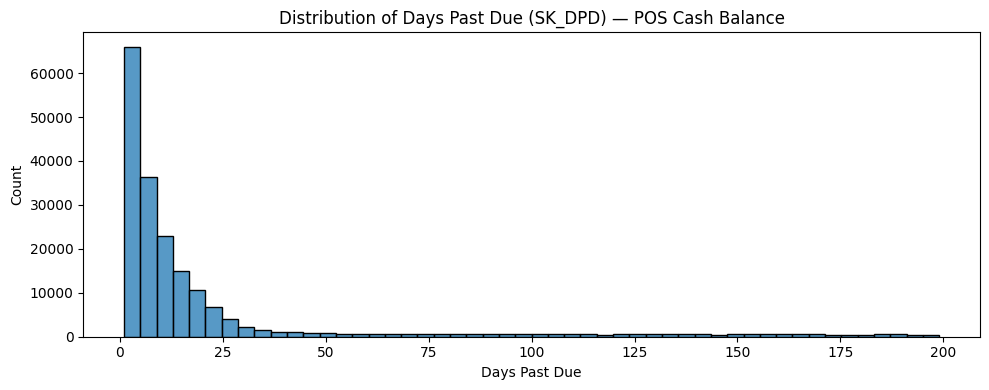

In [13]:
dpd_data = con.execute("""
    SELECT SK_DPD 
    FROM pos 
    WHERE SK_DPD > 0 AND SK_DPD < 200  -- exclude extreme outliers for viz
""").df()

plt.figure(figsize=(10, 4))
sns.histplot(dpd_data['SK_DPD'], bins=50)
plt.title('Distribution of Days Past Due (SK_DPD) — POS Cash Balance')
plt.xlabel('Days Past Due')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [14]:
with open('C:/Users/BeratErcan/Home-Credit-Default-Risk/sql/features/pos_cash_agg.sql', 'r') as f:
    query = f.read()

pos_agg = con.execute(query).df()
print(pos_agg.shape)
pos_agg.head()

(337252, 13)


,SK_ID_CURR,pos_loan_count,pos_total_months,pos_avg_instalment,pos_avg_instalment_future,pos_max_dpd,pos_avg_dpd,pos_late_payment_count,pos_dpd_over_30_count,pos_dpd_over_60_count,pos_late_payment_rate,pos_active_count,pos_completed_count
0,202091,4,29,9.59,5.62,7,0.48,2.00,0.00,0.00,0.07,25.00,4.00
1,220814,4,44,12.45,6.36,8,0.18,1.00,0.00,0.00,0.02,33.00,3.00
2,184200,2,29,19.79,10.72,0,0.00,0.00,0.00,0.00,0.00,26.00,2.00
3,119666,3,54,21.91,13.06,0,0.00,0.00,0.00,0.00,0.00,51.00,3.00
4,347797,2,32,20.38,10.88,0,0.00,0.00,0.00,0.00,0.00,30.00,2.00


In [15]:
con.execute("""
    CREATE VIEW app AS 
    SELECT * FROM read_csv_auto('C:/Users/BeratErcan/Desktop/Data/raw/application_train.csv')
""")

con.execute("""
    SELECT
        COUNT(DISTINCT pos.SK_ID_CURR) as pos_curr_ids,
        COUNT(DISTINCT app.SK_ID_CURR) as app_curr_ids,
        SUM(CASE WHEN app.SK_ID_CURR IS NULL THEN 1 ELSE 0 END) as pos_with_no_match
    FROM pos_agg pos
    LEFT JOIN app ON pos.SK_ID_CURR = app.SK_ID_CURR
""").df()

,pos_curr_ids,app_curr_ids,pos_with_no_match
0,337252,289444,47808.00


In [16]:
pos_agg.describe()

,SK_ID_CURR,pos_loan_count,pos_total_months,pos_avg_instalment,pos_avg_instalment_future,pos_max_dpd,pos_avg_dpd,pos_late_payment_count,pos_dpd_over_30_count,pos_dpd_over_60_count,pos_late_payment_rate,pos_active_count,pos_completed_count
count,337252.00,337252.00,337252.00,337224.00,337224.00,337252.00,337252.00,337252.00,337252.00,337252.00,337252.00,337252.00,337252.00
mean,278163.13,2.78,29.66,14.65,9.18,15.29,4.30,0.88,0.39,0.37,0.02,27.13,2.21
std,102877.89,1.98,24.53,7.97,6.50,151.34,59.72,4.82,4.41,4.34,0.08,22.73,3.17
min,100001.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,189046.75,1.00,12.00,9.62,5.00,0.00,0.00,0.00,0.00,0.00,0.00,11.00,1.00
50%,278241.50,2.00,22.00,12.00,6.99,0.00,0.00,0.00,0.00,0.00,0.00,20.00,2.00
75%,367320.25,4.00,39.00,18.60,11.67,0.00,0.00,0.00,0.00,0.00,0.00,36.00,3.00
max,456255.00,26.00,295.00,72.00,60.00,4231.00,2622.08,169.00,161.00,157.00,1.00,271.00,86.00


In [17]:
pos_agg.isnull().sum()

SK_ID_CURR                    0
pos_loan_count                0
pos_total_months              0
pos_avg_instalment           28
pos_avg_instalment_future    28
pos_max_dpd                   0
pos_avg_dpd                   0
pos_late_payment_count        0
pos_dpd_over_30_count         0
pos_dpd_over_60_count         0
pos_late_payment_rate         0
pos_active_count              0
pos_completed_count           0
dtype: int64

In [18]:
con.execute("""
    SELECT 
        SK_ID_CURR,
        pos_active_count,
        pos_completed_count,
        pos_loan_count,
        pos_total_months
    FROM pos_agg
    WHERE pos_active_count > 100
    ORDER BY pos_active_count DESC
    LIMIT 10
""").df()

,SK_ID_CURR,pos_active_count,pos_completed_count,pos_loan_count,pos_total_months
0,265042,271.00,18.00,20,295
1,185185,231.00,12.00,13,245
2,172612,230.00,17.00,18,247
3,203046,228.00,13.00,17,244
4,443510,226.00,7.00,9,234
5,127659,226.00,14.00,18,245
6,197583,226.00,18.00,23,245
7,362661,225.00,13.00,14,239
8,398407,222.00,15.00,18,237
9,309133,221.00,24.00,26,246


In [19]:
con.execute("""
    SELECT
        SK_ID_CURR,
        pos_max_dpd,
        pos_avg_dpd,
        pos_late_payment_count,
        pos_dpd_over_30_count,
        pos_dpd_over_60_count,
        pos_total_months
    FROM pos_agg
    WHERE pos_dpd_over_30_count > 50
    ORDER BY pos_dpd_over_30_count DESC
    LIMIT 10
""").df()

,SK_ID_CURR,pos_max_dpd,pos_avg_dpd,pos_late_payment_count,pos_dpd_over_30_count,pos_dpd_over_60_count,pos_total_months
0,276629,2460,908.93,169.00,161.00,157.00,218
1,280230,2213,859.51,146.00,144.00,142.00,190
2,437025,2982,932.55,120.00,120.00,120.00,168
3,403158,2702,577.54,108.00,102.00,100.00,216
4,340885,3021,1571.99,96.00,96.00,96.00,96
5,277823,3296,1459.18,97.00,96.00,96.00,118
6,453631,3199,1429.63,96.00,96.00,96.00,114
7,385366,3277,1740.55,96.00,96.00,96.00,101
8,305786,3683,1952.58,96.00,96.00,96.00,110
9,186266,3251,1561.96,96.00,96.00,96.00,109


In [20]:
print(pos_agg['pos_late_payment_rate'].max())  # should be 1.0
print(pos_agg['pos_late_payment_rate'].min())  # should be 0.0

1.0
0.0


## Installments Payments

In [21]:
con.execute("""
    CREATE VIEW installments AS 
    SELECT * FROM read_csv_auto('C:/Users/BeratErcan/Desktop/Data/raw/installments_payments.csv')
""")

In [22]:
con.execute("""
    SELECT
        COUNT(DISTINCT i.SK_ID_PREV) as in_installments,
        COUNT(DISTINCT pa.SK_ID_PREV) as in_prev_app,
        SUM(CASE WHEN pa.SK_ID_PREV IS NULL THEN 1 ELSE 0 END) as installments_with_no_match
    FROM installments i
    LEFT JOIN prev_app pa ON i.SK_ID_PREV = pa.SK_ID_PREV
""").df()

,in_installments,in_prev_app,installments_with_no_match
0,997752,958905,1250826.00


#### It looks like POS_CASH. There are not that many non matching

In [23]:
con.execute("""
    SELECT
        COUNT(*) as total_rows,
        SUM(CASE WHEN SK_ID_PREV IS NULL THEN 1 ELSE 0 END) as null_sk_id_prev,
        SUM(CASE WHEN SK_ID_CURR IS NULL THEN 1 ELSE 0 END) as null_sk_id_curr,
        SUM(CASE WHEN NUM_INSTALMENT_VERSION IS NULL THEN 1 ELSE 0 END) as null_version,
        SUM(CASE WHEN NUM_INSTALMENT_NUMBER IS NULL THEN 1 ELSE 0 END) as null_number,
        SUM(CASE WHEN DAYS_INSTALMENT IS NULL THEN 1 ELSE 0 END) as null_days_instalment,
        SUM(CASE WHEN DAYS_ENTRY_PAYMENT IS NULL THEN 1 ELSE 0 END) as null_days_entry_payment,
        SUM(CASE WHEN AMT_INSTALMENT IS NULL THEN 1 ELSE 0 END) as null_amt_instalment,
        SUM(CASE WHEN AMT_PAYMENT IS NULL THEN 1 ELSE 0 END) as null_amt_payment
    FROM installments
""").df()

,total_rows,null_sk_id_prev,null_sk_id_curr,null_version,null_number,null_days_instalment,null_days_entry_payment,null_amt_instalment,null_amt_payment
0,13605401,0.00,0.00,0.00,0.00,0.00,2905.00,0.00,2905.00


#### Also like POS CASH, and there are not that many Nulls either

In [24]:
# Days instalment = scheduled payment date
# Days entry payment = actual payment date
# Difference = how early or late they paid
con.execute("""
    SELECT
        MIN(DAYS_INSTALMENT) as min_days_scheduled,
        MAX(DAYS_INSTALMENT) as max_days_scheduled,
        MIN(DAYS_ENTRY_PAYMENT) as min_days_paid,
        MAX(DAYS_ENTRY_PAYMENT) as max_days_paid,
        MIN(AMT_INSTALMENT) as min_amt_scheduled,
        MAX(AMT_INSTALMENT) as max_amt_scheduled,
        MIN(AMT_PAYMENT) as min_amt_paid,
        MAX(AMT_PAYMENT) as max_amt_paid
    FROM installments
""").df()

,min_days_scheduled,max_days_scheduled,min_days_paid,max_days_paid,min_amt_scheduled,max_amt_scheduled,min_amt_paid,max_amt_paid
0,-2922.00,-1.00,-4921.00,-1.00,0.00,3771487.85,0.00,3771487.85


In [25]:
con.execute("""
    SELECT
        DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT as payment_delay,
        COUNT(*) as count
    FROM installments
    WHERE DAYS_ENTRY_PAYMENT IS NOT NULL
    GROUP BY payment_delay
    ORDER BY count DESC
    LIMIT 20
""").df()

,payment_delay,count
0,0.00,3146350
1,-1.00,525380
2,-2.00,507963
3,-3.00,459365
4,-9.00,454549
5,-4.00,452509
6,-8.00,447453
7,-6.00,442527
8,-7.00,438668
9,-5.00,438267


#### It looks consistent becasue most people pay on time or early. Honestly it looks very realistic right now

In [26]:
con.execute("""
    CREATE VIEW installments_agg AS
    SELECT
        SK_ID_CURR,

        -- Volume
        COUNT(*)                                                          as inst_total_payments,
        COUNT(DISTINCT SK_ID_PREV)                                        as inst_loan_count,

        -- Payment delay behaviour
        AVG(DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT)                        as inst_avg_payment_delay,
        MAX(DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT)                        as inst_max_payment_delay,
        SUM(CASE WHEN DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT 
            THEN 1 ELSE 0 END)                                           as inst_late_payment_count,
        ROUND(SUM(CASE WHEN DAYS_ENTRY_PAYMENT > DAYS_INSTALMENT 
            THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4)                     as inst_late_payment_rate,

        -- Missed payments (never paid)
        SUM(CASE WHEN DAYS_ENTRY_PAYMENT IS NULL 
            THEN 1 ELSE 0 END)                                           as inst_missed_payment_count,

        -- Payment amount accuracy
        AVG(AMT_PAYMENT - AMT_INSTALMENT)                                as inst_avg_payment_diff,
        SUM(CASE WHEN AMT_PAYMENT < AMT_INSTALMENT 
            THEN 1 ELSE 0 END)                                           as inst_underpayment_count,
        ROUND(SUM(CASE WHEN AMT_PAYMENT < AMT_INSTALMENT 
            THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4)                     as inst_underpayment_rate

    FROM installments
    GROUP BY SK_ID_CURR
""")

inst_agg = con.execute("SELECT * FROM installments_agg").df()
print(inst_agg.shape)
inst_agg.describe()


(339587, 11)


,SK_ID_CURR,inst_total_payments,inst_loan_count,inst_avg_payment_delay,inst_max_payment_delay,inst_late_payment_count,inst_late_payment_rate,inst_missed_payment_count,inst_avg_payment_diff,inst_underpayment_count,inst_underpayment_rate
count,339587.00,339587.00,339587.00,339578.00,339578.00,339587.00,339587.00,339587.00,339578.00,339587.00,339587.00
mean,278154.89,40.06,2.94,-11.26,15.70,3.38,0.07,0.01,390.79,3.81,0.08
std,102880.49,41.05,2.05,12.98,108.72,6.37,0.11,0.26,5242.75,7.99,0.15
min,100001.00,1.00,1.00,-295.00,-156.00,0.00,0.00,0.00,-146145.90,0.00,0.00
25%,189042.50,12.00,1.00,-14.85,-2.00,0.00,0.00,0.00,-435.86,0.00,0.00
50%,278238.00,25.00,2.00,-9.56,1.00,1.00,0.02,0.00,0.00,0.00,0.00
75%,367315.50,51.00,4.00,-5.89,9.00,4.00,0.11,0.00,0.00,4.00,0.11
max,456255.00,372.00,26.00,1884.20,2884.00,159.00,1.00,57.00,337496.80,154.00,1.00


In [27]:
# The person with 1884 days max delay
con.execute("""
    SELECT
        SK_ID_CURR,
        inst_max_payment_delay,
        inst_late_payment_count,
        inst_late_payment_rate,
        inst_missed_payment_count,
        inst_total_payments,
        inst_underpayment_count
    FROM installments_agg
    WHERE inst_max_payment_delay > 1000
    ORDER BY inst_max_payment_delay DESC
    LIMIT 5
""").df()

,SK_ID_CURR,inst_max_payment_delay,inst_late_payment_count,inst_late_payment_rate,inst_missed_payment_count,inst_total_payments,inst_underpayment_count
0,316087,2884.00,9.00,0.09,0.00,105,6.00
1,164168,2882.00,1.00,0.33,0.00,3,2.00
2,210216,2871.00,1.00,0.33,0.00,3,2.00
3,151276,2852.00,1.00,0.20,0.00,5,2.00
4,168241,2852.00,3.00,0.75,0.00,4,2.00


In [28]:
con.execute("""
    SELECT
        SK_ID_CURR,
        inst_avg_payment_diff,
        inst_underpayment_count,
        inst_underpayment_rate,
        inst_total_payments
    FROM installments_agg
    WHERE inst_avg_payment_diff < -10000
    ORDER BY inst_avg_payment_diff ASC
    LIMIT 5
""").df()

,SK_ID_CURR,inst_avg_payment_diff,inst_underpayment_count,inst_underpayment_rate,inst_total_payments
0,332973,-146145.90,3.00,1.00,3
1,235588,-111774.60,7.00,0.70,10
2,298768,-89733.15,8.00,0.80,10
3,111148,-75216.15,6.00,0.18,34
4,197434,-54970.17,4.00,0.11,37


In [29]:
inst_agg.isnull().sum()

SK_ID_CURR                   0
inst_total_payments          0
inst_loan_count              0
inst_avg_payment_delay       9
inst_max_payment_delay       9
inst_late_payment_count      0
inst_late_payment_rate       0
inst_missed_payment_count    0
inst_avg_payment_diff        9
inst_underpayment_count      0
inst_underpayment_rate       0
dtype: int64

#### This looks clean aswell. 
#### The -146,145 underpayment person made 3 payments but underpaid by an average of 146k — likely a large loan they barely touched. The 2884 day delay person paid 1 installment nearly 8 years late across 105 payments.

## Credit Card Balance

In [30]:
con.execute("""
    CREATE VIEW cc AS 
    SELECT * FROM read_csv_auto('C:/Users/BeratErcan/Desktop/Data/raw/credit_card_balance.csv')
""")

In [31]:
con.execute("""
    SELECT 
        MIN(row_count) as min_rows,
        MAX(row_count) as max_rows,
        AVG(row_count) as avg_rows,
        COUNT(*) as unique_prev_ids
    FROM (
        SELECT SK_ID_PREV, COUNT(*) as row_count
        FROM cc
        GROUP BY SK_ID_PREV
    )
""").df()

,min_rows,max_rows,avg_rows,unique_prev_ids
0,1,96,36.82,104307


In [32]:
con.execute("""
    SELECT
        COUNT(DISTINCT cc.SK_ID_PREV) as in_cc,
        COUNT(DISTINCT pa.SK_ID_PREV) as in_prev_app,
        SUM(CASE WHEN pa.SK_ID_PREV IS NULL THEN 1 ELSE 0 END) as cc_with_no_match
    FROM cc
    LEFT JOIN prev_app pa ON cc.SK_ID_PREV = pa.SK_ID_PREV
""").df()

,in_cc,in_prev_app,cc_with_no_match
0,104307,92935,1082816.00


In [33]:
con.execute("""
    SELECT
        COUNT(*) as total_rows,
        SUM(CASE WHEN SK_ID_PREV IS NULL THEN 1 ELSE 0 END) as null_sk_id_prev,
        SUM(CASE WHEN SK_ID_CURR IS NULL THEN 1 ELSE 0 END) as null_sk_id_curr,
        SUM(CASE WHEN MONTHS_BALANCE IS NULL THEN 1 ELSE 0 END) as null_months_balance,
        SUM(CASE WHEN AMT_BALANCE IS NULL THEN 1 ELSE 0 END) as null_amt_balance,
        SUM(CASE WHEN AMT_CREDIT_LIMIT_ACTUAL IS NULL THEN 1 ELSE 0 END) as null_credit_limit,
        SUM(CASE WHEN AMT_DRAWINGS_CURRENT IS NULL THEN 1 ELSE 0 END) as null_drawings,
        SUM(CASE WHEN AMT_PAYMENT_CURRENT IS NULL THEN 1 ELSE 0 END) as null_payment,
        SUM(CASE WHEN SK_DPD IS NULL THEN 1 ELSE 0 END) as null_dpd
    FROM cc
""").df()

,total_rows,null_sk_id_prev,null_sk_id_curr,null_months_balance,null_amt_balance,null_credit_limit,null_drawings,null_payment,null_dpd
0,3840312,0.00,0.00,0.00,0.00,0.00,0.00,767988.00,0.00


In [34]:
con.execute("""
    SELECT
        MIN(AMT_BALANCE) as min_balance,
        MAX(AMT_BALANCE) as max_balance,
        AVG(AMT_BALANCE) as avg_balance,
        MIN(AMT_CREDIT_LIMIT_ACTUAL) as min_limit,
        MAX(AMT_CREDIT_LIMIT_ACTUAL) as max_limit,
        AVG(AMT_CREDIT_LIMIT_ACTUAL) as avg_limit,
        MIN(SK_DPD) as min_dpd,
        MAX(SK_DPD) as max_dpd,
        AVG(SK_DPD) as avg_dpd,
        SUM(CASE WHEN SK_DPD > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as pct_late
    FROM cc
""").df()

,min_balance,max_balance,avg_balance,min_limit,max_limit,avg_limit,min_dpd,max_dpd,avg_dpd,pct_late
0,-420250.18,1505902.19,58300.16,0,1350000,153807.96,0,3260,9.28,3.99


In [35]:
con.execute("DESCRIBE cc").df()

,column_name,column_type,null,key,default,extra
0,SK_ID_PREV,BIGINT,YES,None,None,None
1,SK_ID_CURR,BIGINT,YES,None,None,None
2,MONTHS_BALANCE,BIGINT,YES,None,None,None
3,AMT_BALANCE,DOUBLE,YES,None,None,None
4,AMT_CREDIT_LIMIT_ACTUAL,BIGINT,YES,None,None,None
5,AMT_DRAWINGS_ATM_CURRENT,DOUBLE,YES,None,None,None
6,AMT_DRAWINGS_CURRENT,DOUBLE,YES,None,None,None
7,AMT_DRAWINGS_OTHER_CURRENT,DOUBLE,YES,None,None,None
8,AMT_DRAWINGS_POS_CURRENT,DOUBLE,YES,None,None,None
9,AMT_INST_MIN_REGULARITY,DOUBLE,YES,None,None,None


In [36]:
con.execute("""
    CREATE VIEW cc_agg AS
    SELECT
        SK_ID_CURR,

        -- Volume
        COUNT(*)                                                              as cc_total_months,
        COUNT(DISTINCT SK_ID_PREV)                                            as cc_card_count,

        -- Balance and utilization
        AVG(AMT_BALANCE)                                                      as cc_avg_balance,
        MAX(AMT_BALANCE)                                                      as cc_max_balance,
        AVG(CASE WHEN AMT_CREDIT_LIMIT_ACTUAL > 0 
            THEN AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL 
            ELSE NULL END)                                                    as cc_avg_utilization,
        MAX(CASE WHEN AMT_CREDIT_LIMIT_ACTUAL > 0 
            THEN AMT_BALANCE / AMT_CREDIT_LIMIT_ACTUAL 
            ELSE NULL END)                                                    as cc_max_utilization,

        -- Credit limit
        AVG(AMT_CREDIT_LIMIT_ACTUAL)                                          as cc_avg_limit,
        MAX(AMT_CREDIT_LIMIT_ACTUAL)                                          as cc_max_limit,

        -- Payment behaviour
        AVG(AMT_PAYMENT_TOTAL_CURRENT)                                        as cc_avg_payment,
        SUM(CASE WHEN AMT_PAYMENT_CURRENT IS NULL THEN 1 ELSE 0 END)         as cc_missed_payment_count,
        ROUND(SUM(CASE WHEN AMT_PAYMENT_CURRENT IS NULL 
            THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4)                         as cc_missed_payment_rate,

        -- Drawings
        AVG(AMT_DRAWINGS_CURRENT)                                             as cc_avg_drawings,
        AVG(AMT_DRAWINGS_ATM_CURRENT)                                         as cc_avg_atm_drawings,
        SUM(CNT_DRAWINGS_CURRENT)                                             as cc_total_drawing_count,

        -- DPD
        MAX(SK_DPD)                                                           as cc_max_dpd,
        AVG(SK_DPD)                                                           as cc_avg_dpd,
        SUM(CASE WHEN SK_DPD > 0 THEN 1 ELSE 0 END)                         as cc_late_payment_count,
        ROUND(SUM(CASE WHEN SK_DPD > 0 THEN 1 ELSE 0 END) * 1.0 
            / COUNT(*), 4)                                                   as cc_late_payment_rate

    FROM cc
    GROUP BY SK_ID_CURR
""")

cc_agg = con.execute("SELECT * FROM cc_agg").df()
print(cc_agg.shape)
cc_agg.describe()


(103558, 19)


,SK_ID_CURR,cc_total_months,cc_card_count,cc_avg_balance,cc_max_balance,cc_avg_utilization,cc_max_utilization,cc_avg_limit,cc_max_limit,cc_avg_payment,cc_missed_payment_count,cc_missed_payment_rate,cc_avg_drawings,cc_avg_atm_drawings,cc_total_drawing_count,cc_max_dpd,cc_avg_dpd,cc_late_payment_count,cc_late_payment_rate
count,103558.00,103558.00,103558.00,103558.00,103558.00,102445.00,102445.00,103558.00,103558.00,103558.00,103558.00,103558.00,103558.00,72194.00,103558.00,103558.00,103558.00,103558.00,103558.00
mean,278381.46,37.08,1.01,69973.19,142297.93,0.32,0.62,207320.67,249504.88,10266.21,7.42,0.36,13566.78,12018.18,26.08,16.40,4.11,1.48,0.02
std,102779.52,33.48,0.09,107537.81,171325.54,0.32,0.48,190229.28,201189.09,21915.30,15.70,0.44,26427.65,21302.09,53.26,141.97,44.34,6.12,0.08
min,100006.00,1.00,1.00,-2930.23,0.00,-0.08,0.00,0.00,0.00,0.00,0.00,0.00,-17.58,0.00,0.00,0.00,0.00,0.00,0.00
25%,189536.25,10.00,1.00,0.00,0.00,0.00,0.00,82500.00,112500.00,0.00,0.00,0.00,0.00,1046.51,0.00,0.00,0.00,0.00,0.00
50%,278649.00,22.00,1.00,24997.60,96107.18,0.24,0.94,149000.00,180000.00,3986.60,1.00,0.10,3329.35,4500.00,8.00,0.00,0.00,0.00,0.00
75%,367690.00,75.00,1.00,96997.75,194612.55,0.58,1.04,267500.00,315000.00,11874.11,7.00,1.00,17915.54,15350.39,30.00,0.00,0.00,0.00,0.00
max,456250.00,192.00,4.00,928686.32,1505902.19,2.14,11.78,1350000.00,1350000.00,1591837.27,113.00,1.00,1616206.32,904500.00,2298.00,3260.00,1635.68,94.00,1.00


In [37]:
cc_agg['cc_total_drawing_count'].isnull().sum()

np.int64(0)

In [38]:
cc_agg.isnull().sum()

SK_ID_CURR                     0
cc_total_months                0
cc_card_count                  0
cc_avg_balance                 0
cc_max_balance                 0
cc_avg_utilization          1113
cc_max_utilization          1113
cc_avg_limit                   0
cc_max_limit                   0
cc_avg_payment                 0
cc_missed_payment_count        0
cc_missed_payment_rate         0
cc_avg_drawings                0
cc_avg_atm_drawings        31364
cc_total_drawing_count         0
cc_max_dpd                     0
cc_avg_dpd                     0
cc_late_payment_count          0
cc_late_payment_rate           0
dtype: int64

In [39]:
cc_agg['cc_avg_atm_drawings'] = cc_agg['cc_avg_atm_drawings'].fillna(0) ## These people never made ATM withdrawals so the column was always NULL. lets fill them with 0's.

In [40]:
#Check 1 - Grain
con.execute("""
    SELECT
        COUNT(*) as total_rows,
        COUNT(DISTINCT SK_ID_CURR) as unique_curr_ids,
        COUNT(DISTINCT SK_ID_PREV) as unique_prev_ids
    FROM read_csv_auto('C:/Users/BeratErcan/Desktop/Data/raw/previous_application.csv')
""").df()

,total_rows,unique_curr_ids,unique_prev_ids
0,1670214,338857,1670214


In [41]:
# Check 2 - Key Coverage against main table
con.execute("""
    SELECT
        COUNT(DISTINCT pa.SK_ID_CURR) as in_prev_app,
        COUNT(DISTINCT app.SK_ID_CURR) as in_app_train,
        SUM(CASE WHEN app.SK_ID_CURR IS NULL THEN 1 ELSE 0 END) as prev_with_no_match
    FROM read_csv_auto('C:/Users/BeratErcan/Desktop/Data/raw/previous_application.csv') pa
    LEFT JOIN app ON pa.SK_ID_CURR = app.SK_ID_CURR
""").df()

,in_prev_app,in_app_train,prev_with_no_match
0,338857,291057,256513.00


In [42]:
# Check 3 - Nulls in key columns
con.execute("""
    SELECT
        COUNT(*) as total_rows,
        SUM(CASE WHEN SK_ID_CURR IS NULL THEN 1 ELSE 0 END) as null_sk_id_curr,
        SUM(CASE WHEN SK_ID_PREV IS NULL THEN 1 ELSE 0 END) as null_sk_id_prev,
        SUM(CASE WHEN AMT_CREDIT IS NULL THEN 1 ELSE 0 END) as null_amt_credit,
        SUM(CASE WHEN AMT_APPLICATION IS NULL THEN 1 ELSE 0 END) as null_amt_application,
        SUM(CASE WHEN NAME_CONTRACT_STATUS IS NULL THEN 1 ELSE 0 END) as null_contract_status,
        SUM(CASE WHEN NAME_CONTRACT_TYPE IS NULL THEN 1 ELSE 0 END) as null_contract_type,
        SUM(CASE WHEN DAYS_DECISION IS NULL THEN 1 ELSE 0 END) as null_days_decision
    FROM read_csv_auto('C:/Users/BeratErcan/Desktop/Data/raw/previous_application.csv')
""").df()

,total_rows,null_sk_id_curr,null_sk_id_prev,null_amt_credit,null_amt_application,null_contract_status,null_contract_type,null_days_decision
0,1670214,0.00,0.00,1.00,0.00,0.00,0.00,0.00


## JOINING ALL TABLES

In [43]:
con.execute("""
    CREATE VIEW prev_app_agg AS
    SELECT
        SK_ID_CURR,

        -- Volume
        COUNT(*)                                                              as prev_app_count,
        
        -- Contract types
        SUM(CASE WHEN NAME_CONTRACT_TYPE = 'Cash loans' 
            THEN 1 ELSE 0 END)                                               as prev_cash_loan_count,
        SUM(CASE WHEN NAME_CONTRACT_TYPE = 'Consumer loans' 
            THEN 1 ELSE 0 END)                                               as prev_consumer_loan_count,
        SUM(CASE WHEN NAME_CONTRACT_TYPE = 'Revolving loans' 
            THEN 1 ELSE 0 END)                                               as prev_revolving_loan_count,

        -- Approval status
        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Approved' 
            THEN 1 ELSE 0 END)                                               as prev_approved_count,
        SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Refused' 
            THEN 1 ELSE 0 END)                                               as prev_refused_count,
        ROUND(SUM(CASE WHEN NAME_CONTRACT_STATUS = 'Refused' 
            THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4)                        as prev_refusal_rate,

        -- Amount features
        AVG(AMT_CREDIT)                                                       as prev_avg_credit,
        MAX(AMT_CREDIT)                                                       as prev_max_credit,
        AVG(AMT_APPLICATION)                                                  as prev_avg_application,
        AVG(AMT_DOWN_PAYMENT)                                                 as prev_avg_down_payment,

        -- Credit vs application ratio (did they get what they asked for?)
        AVG(CASE WHEN AMT_APPLICATION > 0 
            THEN AMT_CREDIT / AMT_APPLICATION 
            ELSE NULL END)                                                    as prev_credit_to_app_ratio,

        -- Days features
        MIN(DAYS_DECISION)                                                    as prev_most_recent_app,
        AVG(DAYS_DECISION)                                                    as prev_avg_days_decision

    FROM read_csv_auto('C:/Users/BeratErcan/Desktop/Data/raw/previous_application.csv')
    GROUP BY SK_ID_CURR
""")

prev_agg = con.execute("SELECT * FROM prev_app_agg").df()
print(prev_agg.shape)
prev_agg.isnull().sum()

(338857, 15)


SK_ID_CURR                       0
prev_app_count                   0
prev_cash_loan_count             0
prev_consumer_loan_count         0
prev_revolving_loan_count        0
prev_approved_count              0
prev_refused_count               0
prev_refusal_rate                0
prev_avg_credit                  0
prev_max_credit                  0
prev_avg_application             0
prev_avg_down_payment        20104
prev_credit_to_app_ratio      1105
prev_most_recent_app             0
prev_avg_days_decision           0
dtype: int64

In [44]:
prev_agg['prev_avg_down_payment'] = prev_agg['prev_avg_down_payment'].fillna(0) # Not everybode provides down payment. so null is filled with 0's.

In [45]:
con.execute("""
    CREATE VIEW prev_app_full AS
    SELECT
        p.*,
        
        -- POS features
        pos.pos_loan_count,
        pos.pos_total_months,
        pos.pos_avg_instalment,
        pos.pos_avg_instalment_future,
        pos.pos_max_dpd,
        pos.pos_avg_dpd,
        pos.pos_late_payment_count,
        pos.pos_dpd_over_30_count,
        pos.pos_dpd_over_60_count,
        pos.pos_late_payment_rate,
        pos.pos_active_count,
        pos.pos_completed_count,

        -- Installments features
        inst.inst_total_payments,
        inst.inst_loan_count,
        inst.inst_avg_payment_delay,
        inst.inst_max_payment_delay,
        inst.inst_late_payment_count,
        inst.inst_late_payment_rate,
        inst.inst_missed_payment_count,
        inst.inst_avg_payment_diff,
        inst.inst_underpayment_count,
        inst.inst_underpayment_rate,

        -- Credit card features
        cc.cc_total_months,
        cc.cc_card_count,
        cc.cc_avg_balance,
        cc.cc_max_balance,
        cc.cc_avg_utilization,
        cc.cc_max_utilization,
        cc.cc_avg_limit,
        cc.cc_max_limit,
        cc.cc_avg_payment,
        cc.cc_missed_payment_count,
        cc.cc_missed_payment_rate,
        cc.cc_avg_drawings,
        cc.cc_avg_atm_drawings,
        cc.cc_total_drawing_count,
        cc.cc_max_dpd,
        cc.cc_avg_dpd,
        cc.cc_late_payment_count,
        cc.cc_late_payment_rate

    FROM prev_app_agg p
    LEFT JOIN pos_agg pos ON p.SK_ID_CURR = pos.SK_ID_CURR
    LEFT JOIN installments_agg inst ON p.SK_ID_CURR = inst.SK_ID_CURR
    LEFT JOIN cc_agg cc ON p.SK_ID_CURR = cc.SK_ID_CURR
""")

prev_full = con.execute("SELECT * FROM prev_app_full").df()
print(prev_full.shape)
prev_full.isnull().sum()

(338857, 55)


SK_ID_CURR                        0
prev_app_count                    0
prev_cash_loan_count              0
prev_consumer_loan_count          0
prev_revolving_loan_count         0
prev_approved_count               0
prev_refused_count                0
prev_refusal_rate                 0
prev_avg_credit                   0
prev_max_credit                   0
prev_avg_application              0
prev_avg_down_payment         20104
prev_credit_to_app_ratio       1105
prev_most_recent_app              0
prev_avg_days_decision            0
pos_loan_count                 3005
pos_total_months               3005
pos_avg_instalment             3033
pos_avg_instalment_future      3033
pos_max_dpd                    3005
pos_avg_dpd                    3005
pos_late_payment_count         3005
pos_dpd_over_30_count          3005
pos_dpd_over_60_count          3005
pos_late_payment_rate          3005
pos_active_count               3005
pos_completed_count            3005
inst_total_payments         

In [46]:
# POS nulls — no POS history means 0 activity
pos_cols = [c for c in prev_full.columns if c.startswith('pos_')]
prev_full[pos_cols] = prev_full[pos_cols].fillna(0)

# Installment nulls — no installment history means 0 activity
inst_cols = [c for c in prev_full.columns if c.startswith('inst_')]
prev_full[inst_cols] = prev_full[inst_cols].fillna(0)

# CC nulls — no credit card means 0 activity
cc_cols = [c for c in prev_full.columns if c.startswith('cc_')]
prev_full[cc_cols] = prev_full[cc_cols].fillna(0)

# Keep prev_credit_to_app_ratio nulls for imputer
# Keep prev_avg_down_payment — already filled with 0 earlier

print(prev_full.isnull().sum().sum()) 

21209


In [47]:
prev_full.to_csv('data/processed/prev_app_full.csv', index=False)

In [48]:
import os
os.makedirs('data/processed', exist_ok=True)
prev_full.to_csv('data/processed/prev_app_full.csv', index=False)

In [49]:
# Approval rate — how often were they approved
prev_full['prev_approval_rate'] = (
    prev_full['prev_approved_count'] / prev_full['prev_app_count']
)

# Combined late payment signal across all products
prev_full['overall_late_payment_rate'] = (
    prev_full['pos_late_payment_rate'] * 0.33 +
    prev_full['inst_late_payment_rate'] * 0.33 +
    prev_full['cc_late_payment_rate'] * 0.33
)

# Total missed payments across all products
prev_full['total_missed_payments'] = (
    prev_full['inst_missed_payment_count'] +
    prev_full['cc_missed_payment_count']
)

prev_full = prev_full.replace([float('inf'), float('-inf')], None)

print(prev_full.shape)
prev_full.isnull().sum()[prev_full.isnull().sum() > 0]

(338857, 58)


prev_avg_down_payment       20104
prev_credit_to_app_ratio     1105
dtype: int64

In [50]:
prev_full.to_csv('C:/Users/BeratErcan/Home-Credit-Default-Risk/data/processed/prev_app_full_final.csv', index=False)

import os
size = os.path.getsize('C:/Users/BeratErcan/Home-Credit-Default-Risk/data/processed/prev_app_full_final.csv') / (1024*1024)
print(f"{size:.1f} MB")

107.5 MB
